# Comparación de modelos de machine learning para la predicción de cáncer de pulmón

## Importación de librerías y modelos

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import VarianceThreshold
import optuna
import shap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

# Rutas de la carpeta que guardan los gráficos
output_dir = "resultadosML"
eda_dir = "distribucionDatos"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(eda_dir, exist_ok=True)

print("Librerías importadas correctamente")

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías importadas correctamente


## Dataset y verificación de datos

### Carga de Dataset

In [2]:
DATA_PATH = "data/dataset.csv"

df = pd.read_csv(DATA_PATH, sep=";")
print(f"Datos: {df.shape[0]} filas y {df.shape[1]} columnas")
df.head()

Datos: 5000 filas y 18 columnas


,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,PULMONARY_DISEASE
0,68,1,1,1,1,1,0,57.831178,0,0,1,1,95.977287,1,0,0,0,NO
1,81,1,1,0,0,1,1,47.694835,1,1,0,1,97.184483,0,0,0,0,YES
2,58,1,1,0,0,0,0,59.577435,0,1,1,0,94.974939,0,0,0,0,NO
3,44,0,1,0,1,1,0,59.785767,0,1,0,1,95.187900,0,0,0,0,YES
4,72,0,1,1,1,1,1,59.733941,0,1,0,1,93.503008,0,0,0,0,YES


### Información del Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   AGE                     5000 non-null   int64  
 1   GENDER                  5000 non-null   int64  
 2   SMOKING                 5000 non-null   int64  
 3   FINGER_DISCOLORATION    5000 non-null   int64  
 4   MENTAL_STRESS           5000 non-null   int64  
 5   EXPOSURE_TO_POLLUTION   5000 non-null   int64  
 6   LONG_TERM_ILLNESS       5000 non-null   int64  
 7   ENERGY_LEVEL            5000 non-null   float64
 8   IMMUNE_WEAKNESS         5000 non-null   int64  
 9   BREATHING_ISSUE         5000 non-null   int64  
 10  ALCOHOL_CONSUMPTION     5000 non-null   int64  
 11  THROAT_DISCOMFORT       5000 non-null   int64  
 12  OXYGEN_SATURATION       5000 non-null   float64
 13  CHEST_TIGHTNESS         5000 non-null   int64  
 14  FAMILY_HISTORY          5000 non-null   

In [4]:
df.describe()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE
count,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,57.222800,0.501200,0.666400,0.6012,0.539800,0.516000,0.439200,55.032043,0.394800,0.80040,0.354200,0.698200,94.991029,0.600600,0.301800,0.204000,0.209600
std,15.799224,0.500049,0.471546,0.4897,0.498463,0.499794,0.496339,7.913083,0.488857,0.39974,0.478318,0.459085,1.481048,0.489824,0.459085,0.403009,0.407064
min,30.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,23.258308,0.000000,0.00000,0.000000,0.000000,89.923133,0.000000,0.000000,0.000000,0.000000
25%,44.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,49.440685,0.000000,1.00000,0.000000,0.000000,93.973176,0.000000,0.000000,0.000000,0.000000
50%,57.000000,1.000000,1.000000,1.0000,1.000000,1.000000,0.000000,55.050421,0.000000,1.00000,0.000000,1.000000,94.974073,1.000000,0.000000,0.000000,0.000000
75%,71.000000,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,60.323320,1.000000,1.00000,1.000000,1.000000,95.989272,1.000000,1.000000,0.000000,0.000000
max,84.000000,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,83.046971,1.000000,1.00000,1.000000,1.000000,99.795786,1.000000,1.000000,1.000000,1.000000


In [5]:
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
AGE                       0
GENDER                    0
SMOKING                   0
FINGER_DISCOLORATION      0
MENTAL_STRESS             0
EXPOSURE_TO_POLLUTION     0
LONG_TERM_ILLNESS         0
ENERGY_LEVEL              0
IMMUNE_WEAKNESS           0
BREATHING_ISSUE           0
ALCOHOL_CONSUMPTION       0
THROAT_DISCOMFORT         0
OXYGEN_SATURATION         0
CHEST_TIGHTNESS           0
FAMILY_HISTORY            0
SMOKING_FAMILY_HISTORY    0
STRESS_IMMUNE             0
PULMONARY_DISEASE         0
dtype: int64


## Proceso ETL

### Variable objetivo

In [6]:
target = df.columns[-1]
print(f"\nVariables objetivo: {target}")
print(f"\nValores únicos: {df[target].unique()}")


Variables objetivo: PULMONARY_DISEASE

Valores únicos: ['NO' 'YES']


### Mapeo de variable objetivo

In [7]:
unique_target = df[target].unique()

if 'Yes' in unique_target and 'No' in unique_target:
  df[target] = df[target].map({'Yes': 1, 'No': 0})
elif 'Positive' in unique_target and 'Negative' in unique_target:
  df[target] = df[target].map({'Positive': 1, 'Negative': 0})
else:
  df[target] = pd.factorize(df[target])[0]

print(f"Distribución de variable objetivo: {df[target].value_counts(normalize=True)}")

Distribución de variable objetivo: PULMONARY_DISEASE
0    0.5926
1    0.4074
Name: proportion, dtype: float64


### Verificación final

In [8]:
print(f"Total de nulos en el dataset: {df.isnull().sum().sum()}")

Total de nulos en el dataset: 0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   AGE                     5000 non-null   int64  
 1   GENDER                  5000 non-null   int64  
 2   SMOKING                 5000 non-null   int64  
 3   FINGER_DISCOLORATION    5000 non-null   int64  
 4   MENTAL_STRESS           5000 non-null   int64  
 5   EXPOSURE_TO_POLLUTION   5000 non-null   int64  
 6   LONG_TERM_ILLNESS       5000 non-null   int64  
 7   ENERGY_LEVEL            5000 non-null   float64
 8   IMMUNE_WEAKNESS         5000 non-null   int64  
 9   BREATHING_ISSUE         5000 non-null   int64  
 10  ALCOHOL_CONSUMPTION     5000 non-null   int64  
 11  THROAT_DISCOMFORT       5000 non-null   int64  
 12  OXYGEN_SATURATION       5000 non-null   float64
 13  CHEST_TIGHTNESS         5000 non-null   int64  
 14  FAMILY_HISTORY          5000 non-null   

### Distribución de valores de cada variable binaria

In [39]:
print(f"Distribución de variable GENDER: {df['GENDER'].value_counts(normalize=True)}")
print(f"\nDistribución de variable SMOKING: {df['SMOKING'].value_counts(normalize=True)}")
print(f"\nDistribución de variable FINGER DISCOLORATION: {df['FINGER_DISCOLORATION'].value_counts(normalize=True)}")
print(f"\nDistribución de variable MENTAL STRESS: {df['MENTAL_STRESS'].value_counts(normalize=True)}")
print(f"\nDistribución de variable EXPOSURE TO POLLUTION: {df['EXPOSURE_TO_POLLUTION'].value_counts(normalize=True)}")

Distribución de variable GENDER: GENDER
1    0.5012
0    0.4988
Name: proportion, dtype: float64

Distribución de variable SMOKING: SMOKING
1    0.6664
0    0.3336
Name: proportion, dtype: float64

Distribución de variable FINGER DISCOLORATION: FINGER_DISCOLORATION
1    0.6012
0    0.3988
Name: proportion, dtype: float64

Distribución de variable MENTAL STRESS: MENTAL_STRESS
1    0.5398
0    0.4602
Name: proportion, dtype: float64

Distribución de variable EXPOSURE TO POLLUTION: EXPOSURE_TO_POLLUTION
1    0.516
0    0.484
Name: proportion, dtype: float64


In [37]:
print(f"\nDistribución de variable LONG TERM ILLNESS: {df['LONG_TERM_ILLNESS'].value_counts(normalize=True)}")
print(f"\nDistribución de variable IMMUNE WEAKNESS: {df['IMMUNE_WEAKNESS'].value_counts(normalize=True)}")
print(f"\nDistribución de variable BREATHING ISSUE: {df['BREATHING_ISSUE'].value_counts(normalize=True)}")
print(f"\nDistribución de variable ALCOHOL CONSUMPTION: {df['ALCOHOL_CONSUMPTION'].value_counts(normalize=True)}")


Distribución de variable LONG TERM ILLNESS: LONG_TERM_ILLNESS
0    0.5608
1    0.4392
Name: proportion, dtype: float64

Distribución de variable IMMUNE WEAKNESS: IMMUNE_WEAKNESS
0    0.6052
1    0.3948
Name: proportion, dtype: float64

Distribución de variable BREATHING ISSUE: BREATHING_ISSUE
1    0.8004
0    0.1996
Name: proportion, dtype: float64

Distribución de variable ALCOHOL CONSUMPTION: ALCOHOL_CONSUMPTION
0    0.6458
1    0.3542
Name: proportion, dtype: float64


In [38]:
print(f"\nDistribución de variable THROAT DISCOMFORT: {df['THROAT_DISCOMFORT'].value_counts(normalize=True)}")
print(f"\nDistribución de variable CHEST TIGHTNESS: {df['CHEST_TIGHTNESS'].value_counts(normalize=True)}")
print(f"\nDistribución de variable FAMILY HISTORY: {df['FAMILY_HISTORY'].value_counts(normalize=True)}")
print(f"\nDistribución de variable SMOKING FAMILY HISTORY: {df['SMOKING_FAMILY_HISTORY'].value_counts(normalize=True)}")
print(f"\nDistribución de variable STRESS_IMMUNE: {df['STRESS_IMMUNE'].value_counts(normalize=True)}")


Distribución de variable THROAT DISCOMFORT: THROAT_DISCOMFORT
1    0.6982
0    0.3018
Name: proportion, dtype: float64

Distribución de variable CHEST TIGHTNESS: CHEST_TIGHTNESS
1    0.6006
0    0.3994
Name: proportion, dtype: float64

Distribución de variable FAMILY HISTORY: FAMILY_HISTORY
0    0.6982
1    0.3018
Name: proportion, dtype: float64

Distribución de variable SMOKING FAMILY HISTORY: SMOKING_FAMILY_HISTORY
0    0.796
1    0.204
Name: proportion, dtype: float64

Distribución de variable STRESS_IMMUNE: STRESS_IMMUNE
0    0.7904
1    0.2096
Name: proportion, dtype: float64


## Análisis exploratorio de datos (EDA)

In [10]:
df_eda = df.copy()
df_eda[target] = df_eda[target].astype(str) # String para las etiquetas

### Histograma de edad

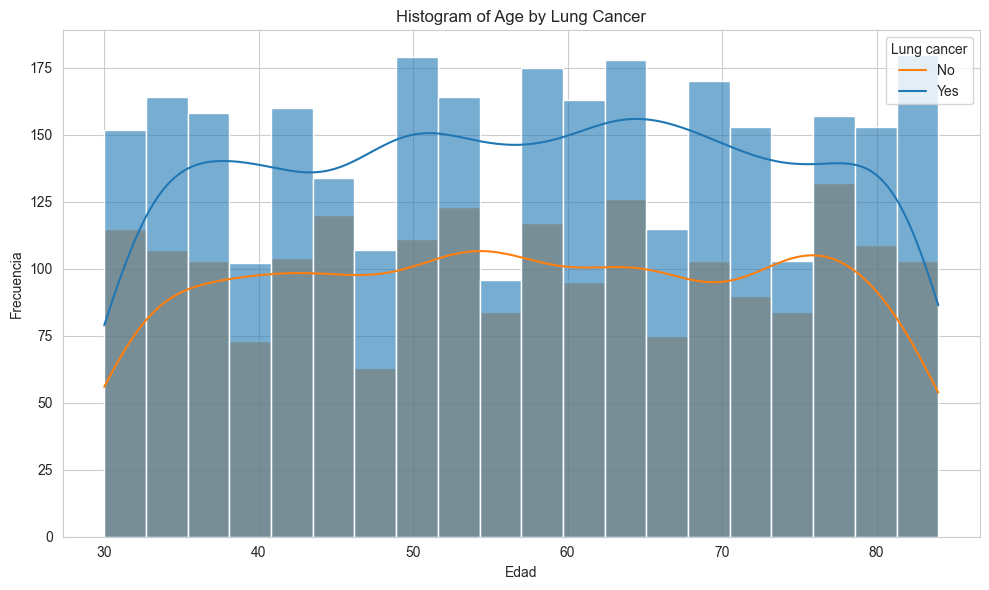

In [11]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_eda, x='AGE', hue=target, kde=True, alpha=0.6, bins=20)
plt.title('Histogram of Age by Lung Cancer')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend(title='Lung cancer', labels=['No','Yes'])
plt.tight_layout()
plt.savefig(os.path.join(eda_dir, 'hist_age_lung_cancer'), dpi=150)
plt.show()

### Gráfico de género

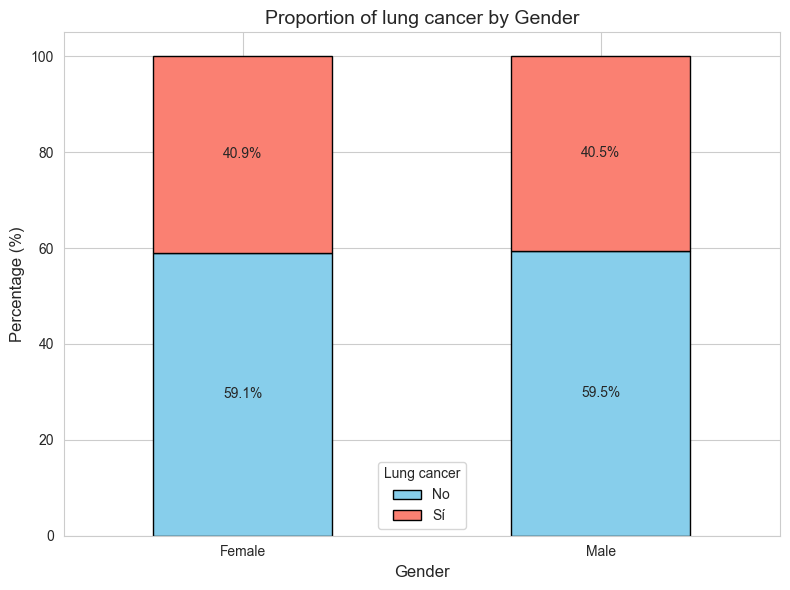

In [ ]:
df_plot = df.copy()
df_plot[target] = df_plot[target].map({0: 'No', 1: 'Yes'})
df_plot['GENDER_label'] = df_plot['GENDER'].map({0: 'Female', 1: 'Male'})
df_plot['SMOKING_label'] = df_plot['SMOKING'].map({0: 'No smoker', 1: 'Smoker'})

plt.figure(figsize=(8,6))
# Calcular porcentajes por género
gender_counts = pd.crosstab(df_plot['GENDER_label'], df_plot[target], normalize='index') * 100
gender_counts.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'], edgecolor='black', ax=plt.gca())
plt.title('Proportion of lung cancer by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Lung cancer', labels=['No', 'Sí'])
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(eda_dir, 'gender_lung_cancer.png'), dpi=150)
plt.show()

### Gráfico de tabaquismo

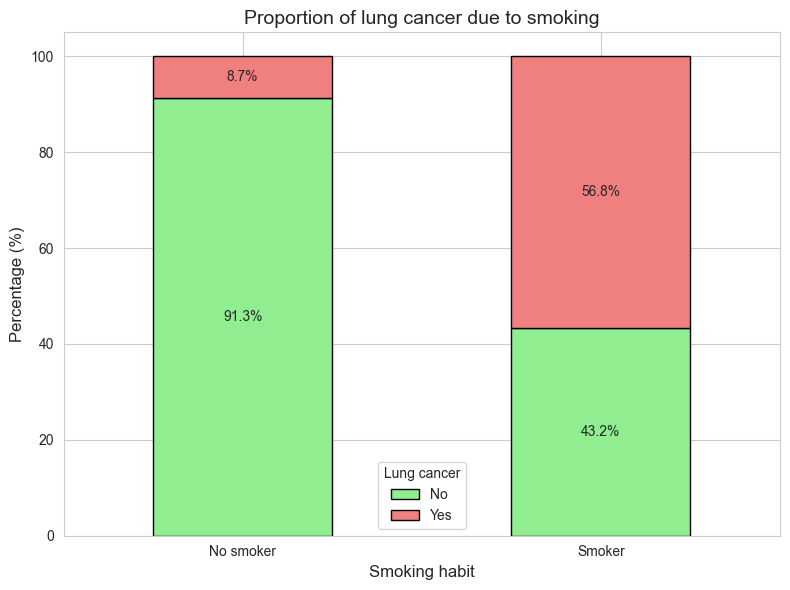

In [14]:
plt.figure(figsize=(8,6))
smoking_counts = pd.crosstab(df_plot['SMOKING_label'], df_plot[target], normalize='index') * 100
smoking_counts.plot(kind='bar', stacked=True, color=['lightgreen', 'lightcoral'], edgecolor='black', ax=plt.gca())
plt.title('Proportion of lung cancer due to smoking', fontsize=14)
plt.xlabel('Smoking habit', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Lung cancer', labels=['No', 'Yes'])
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(eda_dir, 'smoking_lung_cancer.png'), dpi=150)
plt.show()

### Boxplots de variables numéricas

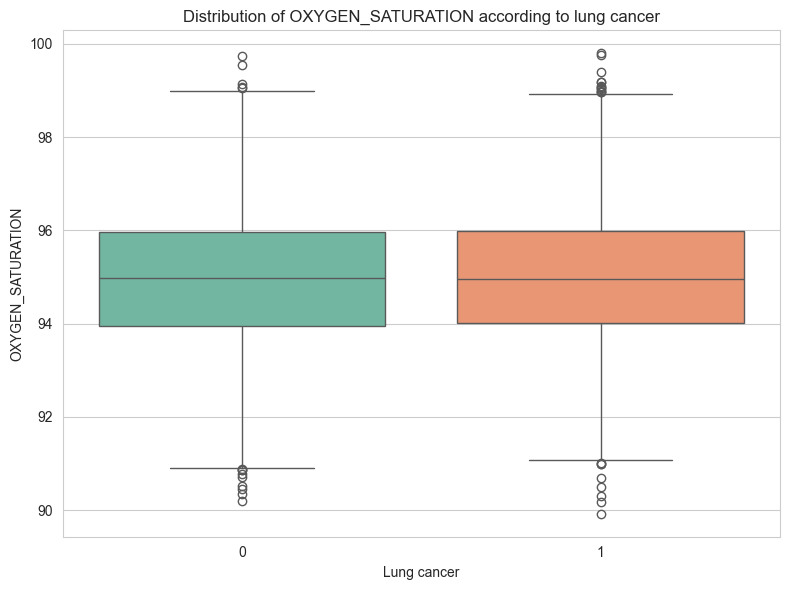

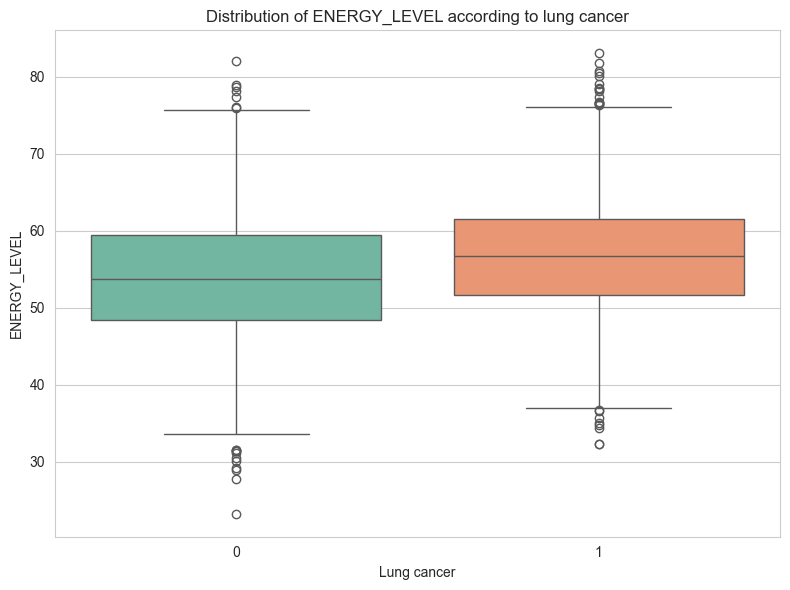

In [15]:
num_vars = ['OXYGEN_SATURATION','ENERGY_LEVEL']
for var in num_vars:
  plt.figure(figsize=(8,6))
  sns.boxplot(data=df_eda, x=target, y=var, palette='Set2')
  plt.title(f'Distribution of {var} according to lung cancer')
  plt.xlabel('Lung cancer')
  plt.ylabel(var)
  plt.tight_layout()
  plt.savefig(os.path.join(eda_dir, f'boxplot_{var.lower()}_lung_cancer.png'), dpi=150)
  plt.show()

In [44]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")
    return outliers

for col in ['ENERGY_LEVEL', 'OXYGEN_SATURATION']:
    out = detect_outliers_iqr(df, col)
    if len(out) > 0:
        print(out[[col, target]].head())

ENERGY_LEVEL: 31 outliers (0.62%)
      ENERGY_LEVEL  PULMONARY_DISEASE
249      77.325987                  0
441      32.294964                  1
603      83.046971                  1
758      31.117897                  0
1103     78.129695                  0
OXYGEN_SATURATION: 30 outliers (0.60%)
     OXYGEN_SATURATION  PULMONARY_DISEASE
84           90.341484                  0
235          90.312177                  1
451          99.180708                  1
628          90.168116                  1
766          90.870809                  0


En las variables `OXYGEN_SATURATION` y `ENERGY_LEVEL` se detectaron algunos valores que podrían considerarse atípicos según criterios estadísticos (e.g., percentiles 1% y 99%). Sin embargo, **se decidió mantenerlos sin modificar** por las siguientes razones:

- **Relevancia clínica**: En el contexto médico, valores como saturación de oxígeno del 90% o niveles de energía extremadamente bajos/altos son perfectamente posibles y reflejan condiciones reales de los pacientes (hipoxemia leve en enfermedad pulmonar, o alta energía en individuos sanos). Eliminarlos supondría perder información valiosa.

- **Baja proporción**: Los outliers representan menos del 1% del total de las observaciones (< 0.62% en `ENERGY_LEVEL` y < 0.60% en `OXYGEN_SATURATION`), por lo que su impacto en el entrenamiento de los modelos es mínimo.

Por todo ello, se optó por conservar los datos originales sin aplicar ningún filtro ni transformación adicional por outliers.

### Correlación de las variables

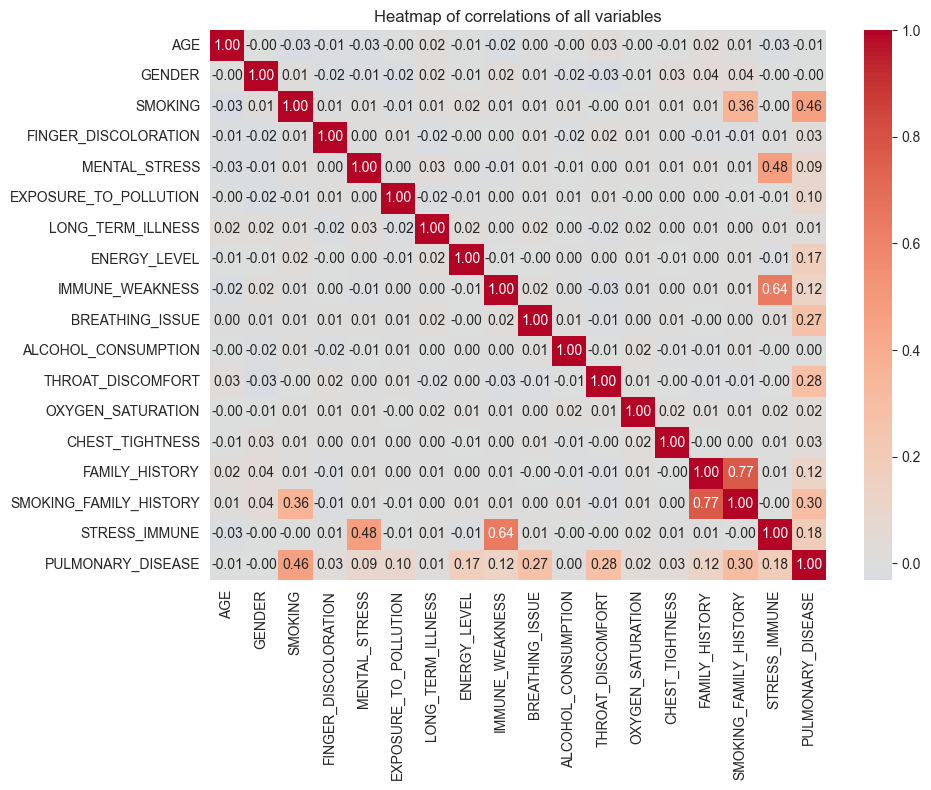

In [16]:
plt.figure(figsize=(10, 8))  
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Heatmap of correlations of all variables')
plt.tight_layout()
file_path_plot = os.path.join(eda_dir, "correlation_variable.png")
plt.savefig(file_path_plot)

plt.show()

### Correlación de variables con variable objetivo

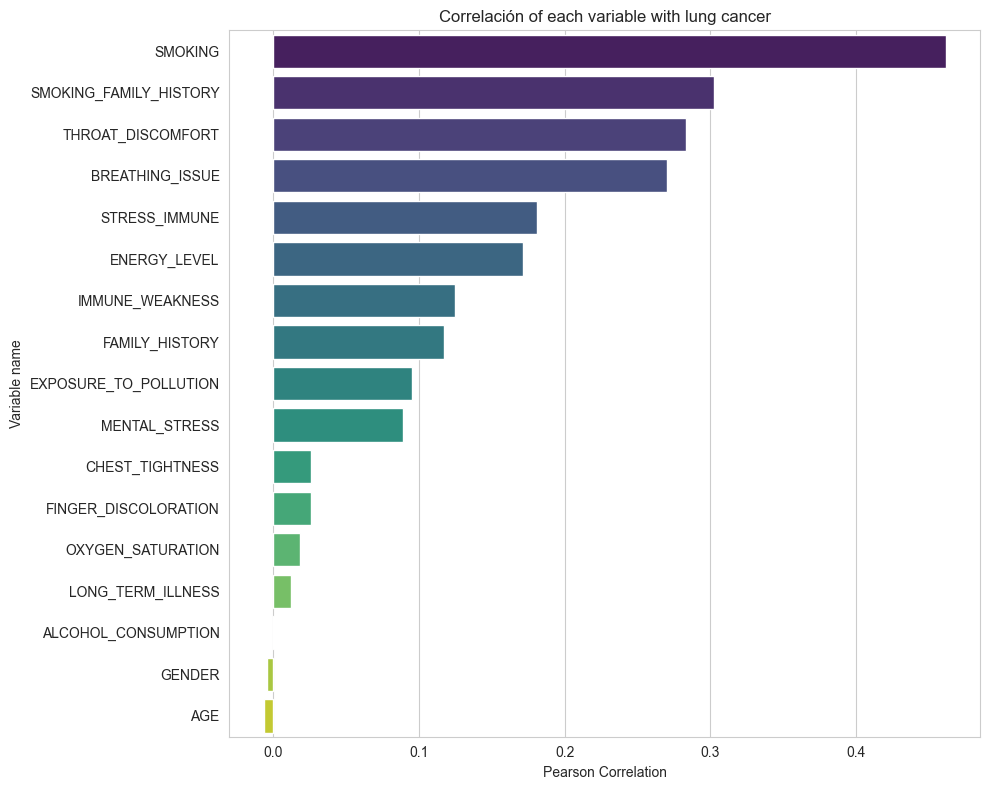

Gráfico guardado en: distribucionDatos\correlation_with_lung_cancer.png


In [ ]:
# Calcular correlación con el objetivo y ordenar
corr_target = df.corr()[target].drop(target).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=corr_target.values, y=corr_target.index, palette='viridis')
plt.title('Correlación of each variable with lung cancer')
plt.xlabel('Pearson Correlation')
plt.ylabel('Variable name')
plt.tight_layout()
file_path_plot = os.path.join(eda_dir, "correlation_with_lung_cancer.png")
plt.savefig(file_path_plot)

plt.show()
print(f"Gráfico guardado en: {file_path_plot}")

## Ingeniería de características avanzada

In [19]:
# Copia de trabajo
df_feat = df.copy()

### Eliminar columnas con varianza muy baja
No se elimina ninguna debido a que no hay varianzas menor a 0.01

In [21]:
X_temp = df_feat.drop(columns=target)
selector_var = VarianceThreshold(threshold=0.01)
X_high_var = selector_var.fit_transform(X_temp)
cols_keep = X_temp.columns[selector_var.get_support()]
df_feat = pd.concat([df_feat[cols_keep], df_feat[target]], axis=1)
print(f"Columnas con baja varianza eliminadas. Nuevo tamañada: {df_feat.shape}")

Columnas con baja varianza eliminadas. Nuevo tamañada: (5000, 18)


### Importancia de características con Random Forest

In [22]:
X_imp = df_feat.drop(columns=[target])
y_imp = df_feat[target]
rf_imp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_imp.fit(X_imp, y_imp)
importancias = pd.Series(rf_imp.feature_importances_, index=X_imp.columns)
top5 = importancias.nlargest(5).index.tolist()
print(f"Top 5 características: {top5}")

Top 5 características: ['SMOKING', 'ENERGY_LEVEL', 'THROAT_DISCOMFORT', 'BREATHING_ISSUE', 'OXYGEN_SATURATION']


### Crear interacciones multiplicativas

In [23]:
# Interacciones multiplicativas 
for i in range(len(top5)):
  for j in range(i+1, len(top5)):
    df_feat[f'{top5[i]}_x_{top5[j]}'] = df_feat[top5[i]] * df_feat[top5[j]]

print(f"Interacciones añadidas: {len(top5)*(len(top5)-1)//2}. Tamaño final: {df_feat.shape}") # 5 * 4 / 2 = 10

Interacciones añadidas: 10. Tamaño final: (5000, 28)


In [25]:
# Reemplazar dataset original
df = df_feat.copy()
print(f"\nDataset final para modelado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.info()


Dataset final para modelado: 5000 filas, 28 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   AGE                                    5000 non-null   int64  
 1   GENDER                                 5000 non-null   int64  
 2   SMOKING                                5000 non-null   int64  
 3   FINGER_DISCOLORATION                   5000 non-null   int64  
 4   MENTAL_STRESS                          5000 non-null   int64  
 5   EXPOSURE_TO_POLLUTION                  5000 non-null   int64  
 6   LONG_TERM_ILLNESS                      5000 non-null   int64  
 7   ENERGY_LEVEL                           5000 non-null   float64
 8   IMMUNE_WEAKNESS                        5000 non-null   int64  
 9   BREATHING_ISSUE                        5000 non-null   int64  
 10  ALCOHOL_CONSUMPTIO

## Entrenamiento de modelos predictivos

### División entrenamiento/prueba

In [ ]:
X = df.drop(columns=[target]) # Características
y = df[target]                # Variable objetivo

# Entrenamiento/prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} | Prueba: {X_test.shape[0]}")


Entrenamiento: 4000 | Prueba: 1000


### Escalado

In [ ]:
# Identificar columnas continuas 
continuous_cols = ['ENERGY_LEVEL', 'OXYGEN_SATURATION']
continuous_cols = [col for col in continuous_cols if col in X_train.columns]

# Escalado de columnas numéricas (valores 0 a 1)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
# Escalar columnas numéricas identificadas
for col in continuous_cols:
  X_train_scaled[col] = scaler.fit_transform(X_train[[col]]).ravel() # Calcula parámetros necesarios y transforma en esos mismos datos. Solo se usa en X_train (ravel para vector 1D)
  X_test_scaled[col] = scaler.transform(X_test[[col]]).ravel()       # Utiliza parámetros ya calculados. Solo se usa en X_test (ravel para vector 1D)

### Oversampling y validación cruzada estratificada

In [ ]:
# Aumento de datos con SMOTE al conjunto de entrenamiento (oversampling)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f"Tamaño original de entrenamiento: {X_train.shape[0]}")
print(f"Tamaño alterado con SMOTE de entrenamiento: {X_train_resampled.shape[0]}")
print(f"Distribución de valors en variable objetivo: {pd.Series(y_train_resampled).value_counts(normalize=True)}")

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

Tamaño original de entrenamiento: 4000
Tamaño alterado con SMOTE de entrenamiento: 4740
Distribución de valors en variable objetivo: PULMONARY_DISEASE
0    0.5
1    0.5
Name: proportion, dtype: float64


## Definición de modelos

In [33]:
# Diccionario que guarda el modelo de ML y los hiperparámetros a probar de cada modelo

models_params = {
  'LogisticRegression': {
    'model': LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced'),
    'params': {
      'C': [0.01, 0.1, 1, 10, 100], 
      'solver': ['lbfgs']
    }
  },
  'RandomForest': {
    'model': RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    'params': {
      'n_estimators': [100, 200, 300],
      'max_depth': [5, 10, 20, None],
      'min_samples_split': [2, 5, 10],
      'min_samples_leaf': [1, 2, 4]
    }
  },
  'SVM_RBF': { 
    'model': SVC(probability=True, random_state=42, class_weight='balanced'),
    'params': {
      'C': [0.1, 1, 10, 100],
      'gamma': ['scale', 'auto', 0.1],
      'kernel': ['rbf']
    }
   },
  'KNN': {
    'model': KNeighborsClassifier(),
    'params': {
      'n_neighbors': [3, 5, 7, 9, 11, 15],
      'weights': ['uniform', 'distance'],
      'p': [1, 2]
    }
  },
  'GradientBoosting': {
    'model': GradientBoostingClassifier(random_state=42),
    'params': {
      'n_estimators': [100, 200, 300],
      'learning_rate': [0.01, 0.05, 0.1, 0.2],
      'max_depth': [3, 5, 7],
      'subsample': [0.8, 1.0]
    }
  },
  'CatBoost': {
    'model': CatBoostClassifier(verbose=0, random_state=42, auto_class_weights='Balanced'),
    'params': {
      'iterations': [100, 200, 300],
      'depth': [4, 6, 8, 10],
      'learning_rate': [0.01, 0.05, 0.1],
      'l2_leaf_reg': [1, 3, 5]
    }
  }
}

### Optimización de XGBoost con Optuna

In [34]:
best_models = {}

def objective(trial):
  params = {
    'n_estimators': trial.suggest_int('n_estimators', 100, 400),    
    'max_depth': trial.suggest_int('max_depth', 3, 8),
    'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
    'subsample': trial.suggest_float('subsample', 0.6, 1.0),
    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    'gamma': trial.suggest_float('gamma', 0, 3),
    'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
    'reg_lambda': trial.suggest_float('reg_lambda', 0, 2),
    'random_state': 42,
    'eval_metric': 'logloss',
    'use_label_encoder': False,
    'early_stopping_rounds': 10
  }
  # Validación cruzada manual para AUC
  auc_scores = []
  for train_idx, val_idx in cv.split(X_train_resampled, y_train_resampled):
      X_tr, X_val = X_train_resampled.iloc[train_idx], X_train_resampled.iloc[val_idx]
      y_tr, y_val = y_train_resampled.iloc[train_idx], y_train_resampled.iloc[val_idx]
      model = XGBClassifier(**params)
      model.fit(X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                verbose=False)
      y_proba = model.predict_proba(X_val)[:, 1]
      auc_scores.append(roc_auc_score(y_val, y_proba))
  return np.mean(auc_scores)


print("\nOptimizando XGBoost con Optuna...")
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20, show_progress_bar=True)
best_xgb_params = study.best_params
print("Mejores hiperparámetros para XGBoost:", best_xgb_params)

# Entrenar XGBoost final con todos los datos
xgb_best = XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_best.fit(X_train_resampled, y_train_resampled)
best_models['XGBoost'] = xgb_best

[I 2026-05-14 20:56:39,468] A new study created in memory with name: no-name-73f07462-2275-4245-9ae6-dbe8f67ae741



Optimizando XGBoost con Optuna...


Best trial: 0. Best value: 0.928777:   5%|▌         | 1/20 [00:00<00:18,  1.03it/s]

[I 2026-05-14 20:56:40,471] Trial 0 finished with value: 0.9287769054104577 and parameters: {'n_estimators': 212, 'max_depth': 8, 'learning_rate': 0.07441632389160634, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.46798356100860794, 'reg_alpha': 0.11616722433639892, 'reg_lambda': 1.7323522915498704}. Best is trial 0 with value: 0.9287769054104577.


Best trial: 0. Best value: 0.928777:  10%|█         | 2/20 [00:02<00:26,  1.47s/it]

...

[I 2026-05-14 20:56:53,981] Trial 17 finished with value: 0.925808631095444 and parameters: {'n_estimators': 164, 'max_depth': 7, 'learning_rate': 0.04688200608494317, 'subsample': 0.6697274314999843, 'colsample_bytree': 0.7954333166739153, 'gamma': 2.1808942553641333, 'reg_alpha': 0.32336181025558103, 'reg_lambda': 1.677719847366791}. Best is trial 12 with value: 0.9292837686268228.


Best trial: 12. Best value: 0.929284:  95%|█████████▌| 19/20 [00:15<00:00,  1.27it/s]

[I 2026-05-14 20:56:54,946] Trial 18 finished with value: 0.9231469315814773 and parameters: {'n_estimators': 222, 'max_depth': 5, 'learning_rate': 0.02155567641651863, 'subsample': 0.8029967056557425, 'colsample_bytree': 0.6479387971392992, 'gamma': 1.0814780413434173, 'reg_alpha': 1.9859918690466813, 'reg_lambda': 1.1790748997873965}. Best is trial 12 with value: 0.9292837686268228.


Best trial: 12. Best value: 0.929284: 100%|██████████| 20/20 [00:15<00:00,  1.26it/s]


[I 2026-05-14 20:56:55,376] Trial 19 finished with value: 0.927158040912247 and parameters: {'n_estimators': 302, 'max_depth': 8, 'learning_rate': 0.10277745967063956, 'subsample': 0.7695956616104436, 'colsample_bytree': 0.8383240684661064, 'gamma': 1.5043710462670996, 'reg_alpha': 1.0907983132941612, 'reg_lambda': 1.5865178248254408}. Best is trial 12 with value: 0.9292837686268228.
Mejores hiperparámetros para XGBoost: {'n_estimators': 186, 'max_depth': 7, 'learning_rate': 0.07459643403674823, 'subsample': 0.8566880772987617, 'colsample_bytree': 0.7839091179543534, 'gamma': 0.025625119309733685, 'reg_alpha': 0.9374104377756844, 'reg_lambda': 1.4843847042464453}


### Optimización de los otros modelos con RandomizedSearchCV

In [35]:

# Optimización del resto de modelos con RandomizedSearchCV
for name, mp in models_params.items():
  print(f"\nOptimizando {name} con RandomizedSearchCV...")
  model = mp['model'] 
  param_dist = mp['params']

  random_search = RandomizedSearchCV(
    model, param_distributions=param_dist, n_iter=15,
    cv=cv, scoring='roc_auc', random_state=42, n_jobs=-1
  )
  random_search.fit(X_train_resampled, y_train_resampled)
  print(f"Mejores parámetros para {name}: {random_search.best_params_}")

  # Entrenar modelo final con todos los datos
  final_model = random_search.best_estimator_
  final_model.fit(X_train_resampled, y_train_resampled)
  best_models[name] = final_model
  
  


Optimizando LogisticRegression con RandomizedSearchCV...
Mejores parámetros para LogisticRegression: {'solver': 'lbfgs', 'C': 10}

Optimizando RandomForest con RandomizedSearchCV...
Mejores parámetros para RandomForest: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}

Optimizando SVM_RBF con RandomizedSearchCV...
Mejores parámetros para SVM_RBF: {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}

Optimizando KNN con RandomizedSearchCV...
Mejores parámetros para KNN: {'weights': 'distance', 'p': 1, 'n_neighbors': 15}

Optimizando GradientBoosting con RandomizedSearchCV...
Mejores parámetros para GradientBoosting: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05}

Optimizando CatBoost con RandomizedSearchCV...
Mejores parámetros para CatBoost: {'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 300, 'depth': 8}


### Evaluación en test

In [36]:
# Función para evaluar un modelo ya entrenado en test
def evaluate_model(model, X_test, y_test, model_name):
  y_pred = model.predict(X_test)
  try:
    y_proba = model.predict_proba(X_test)[:, 1]
  except AttributeError:
    y_proba = model.decision_function(X_test)
  metrics = {
    'Model': model_name,
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_proba)
  }
  return metrics, y_proba

results = []
probas_dict = {}

for name, model in best_models.items():
  metrics, y_proba = evaluate_model(model, X_test_scaled, y_test, name)
  results.append(metrics)
  probas_dict[name] = y_proba

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('AUC', ascending=False)
print("\nResultados finales:\n", results_df.round(4))

# Guardar en carpeta resultadosML
file_path = os.path.join(output_dir, "resultados_modelos.csv")
results_df.to_csv(file_path, index=True)
print(f"\nArchivo guardado en: {file_path}")


Resultados finales:
                     Accuracy  Precision  Recall      F1     AUC
Model                                                          
LogisticRegression     0.872     0.8053  0.9042  0.8519  0.9217
CatBoost               0.900     0.8646  0.8943  0.8792  0.9199
XGBoost                0.888     0.8554  0.8722  0.8637  0.9185
RandomForest           0.890     0.8478  0.8894  0.8681  0.9148
GradientBoosting       0.891     0.8548  0.8821  0.8682  0.9113
SVM_RBF                0.745     0.6392  0.8575  0.7324  0.8700
KNN                    0.796     0.7261  0.8010  0.7617  0.8598

Archivo guardado en: resultadosML\resultados_modelos.csv


## Markdown

### Gráfico de barras comparativo

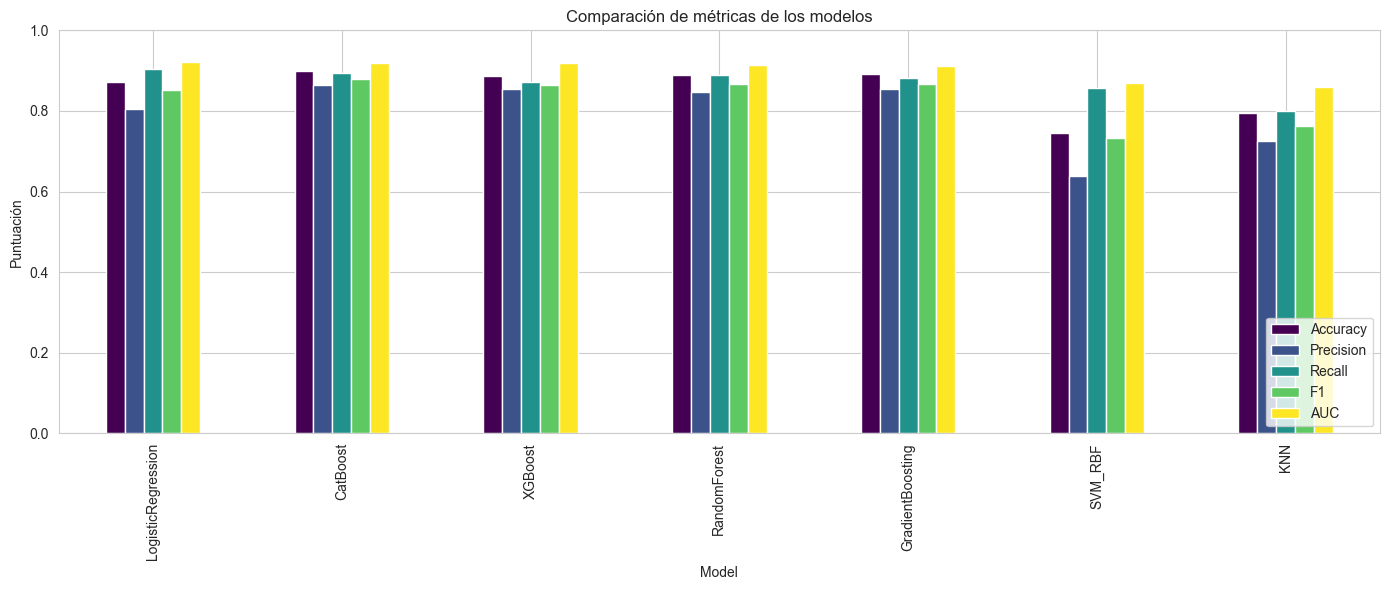

Gráfico guardado en: resultadosML\barras_comparativas_modelos.png


In [37]:
# Métricas a graficar
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']

# Gráfico de barras
results_df[metrics_to_plot].plot(kind='bar', figsize=(14, 6), colormap='viridis')

plt.title('Comparación de métricas de los modelos')
plt.ylabel('Puntuación')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()

file_path_plot = os.path.join(output_dir, "barras_comparativas_modelos.png")
plt.savefig(file_path_plot)

plt.show()
print(f"Gráfico guardado en: {file_path_plot}")

### Matrices de confusión para cada modelo

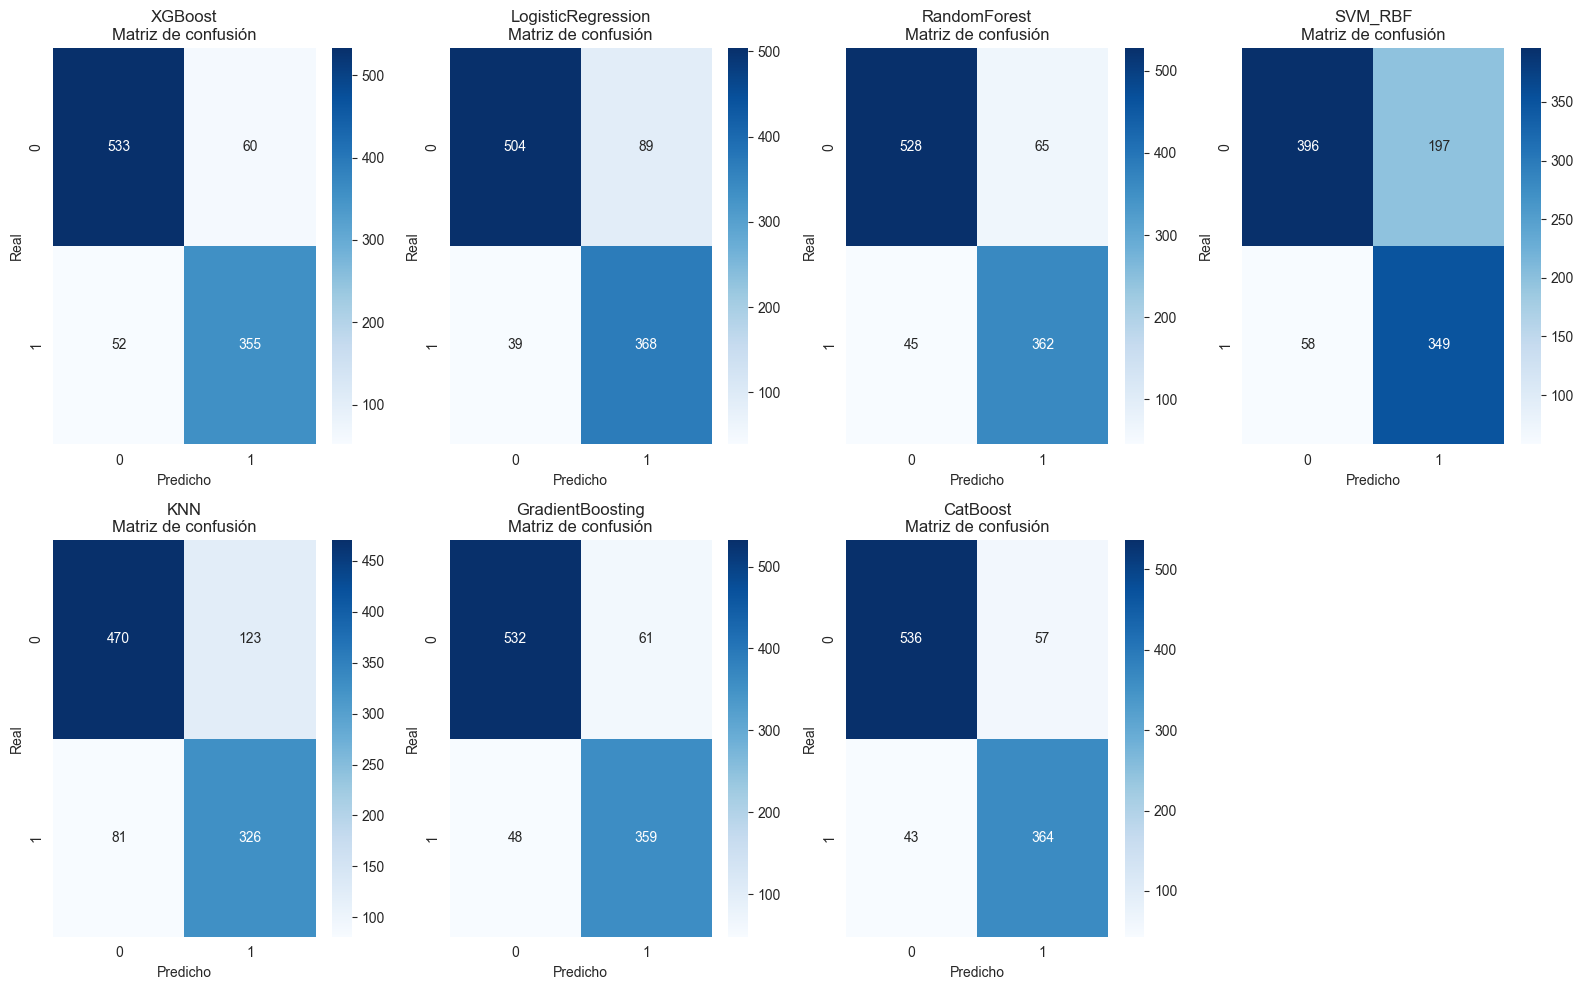

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16,10))
axes = axes.flatten()
for idx, (name, model) in enumerate(best_models.items()):
  y_pred = model.predict(X_test_scaled)
  cm = confusion_matrix(y_test, y_pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
  axes[idx].set_title(f'{name}\nMatriz de confusión')
  axes[idx].set_xlabel('Predicho')
  axes[idx].set_ylabel('Real')

# Ocultar último subplot
if len(best_models) < 8:
  axes[-1].axis('off')
plt.tight_layout()
file_path_plot = os.path.join(output_dir, "matrices_confusion.png")
plt.savefig(file_path_plot)

plt.show()
print(f"Gráfico guardado en: {file_path_plot}")

### Curva ROC para cada modelo

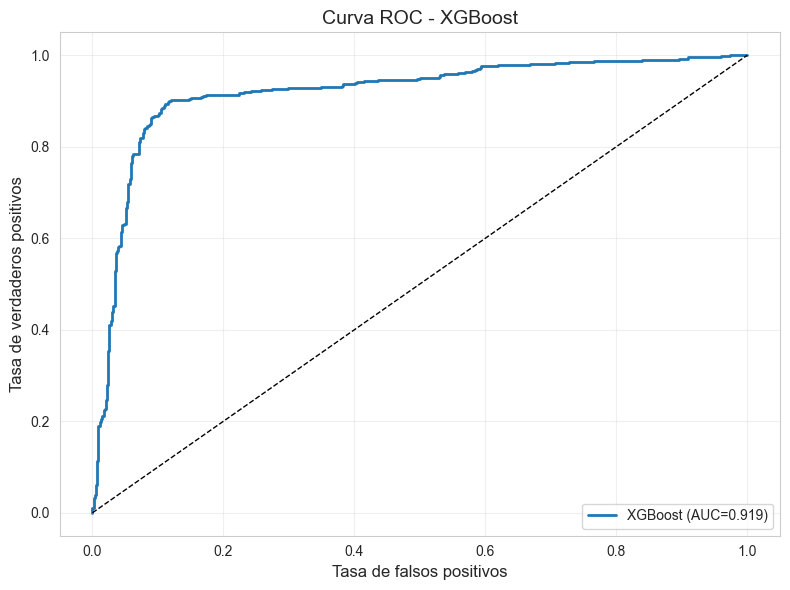

ROC guardada en: resultadosML\roc_XGBoost.png


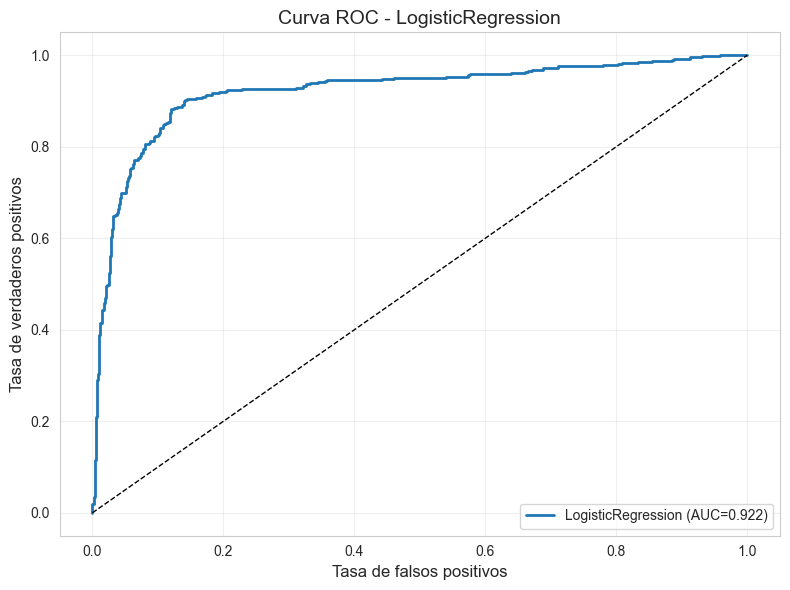

ROC guardada en: resultadosML\roc_LogisticRegression.png


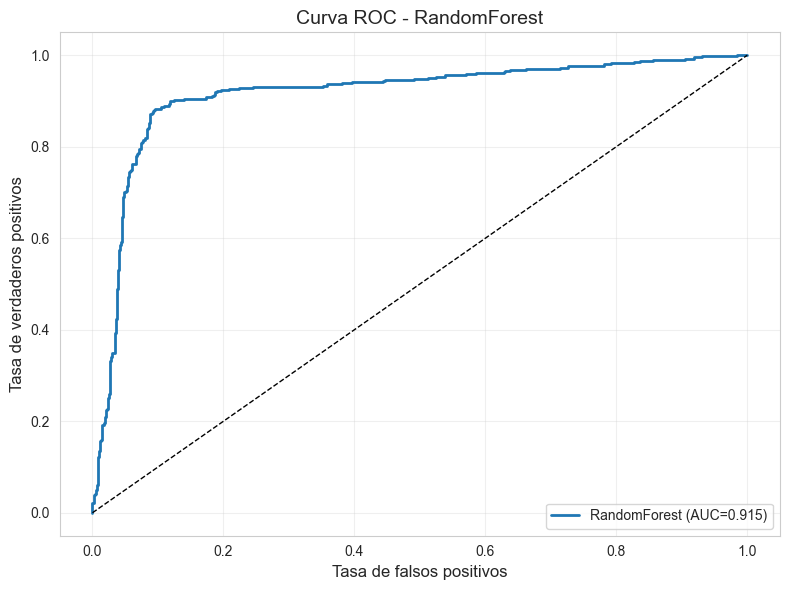

ROC guardada en: resultadosML\roc_RandomForest.png


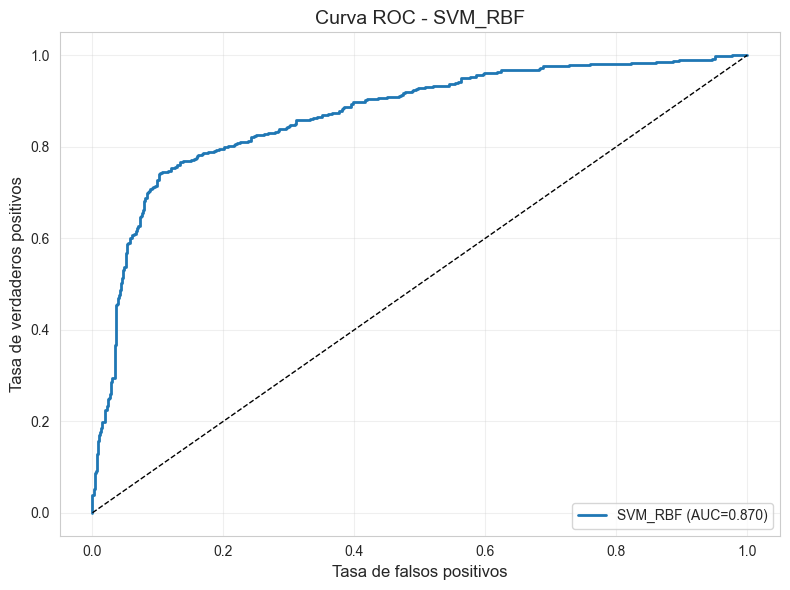

ROC guardada en: resultadosML\roc_SVM_RBF.png


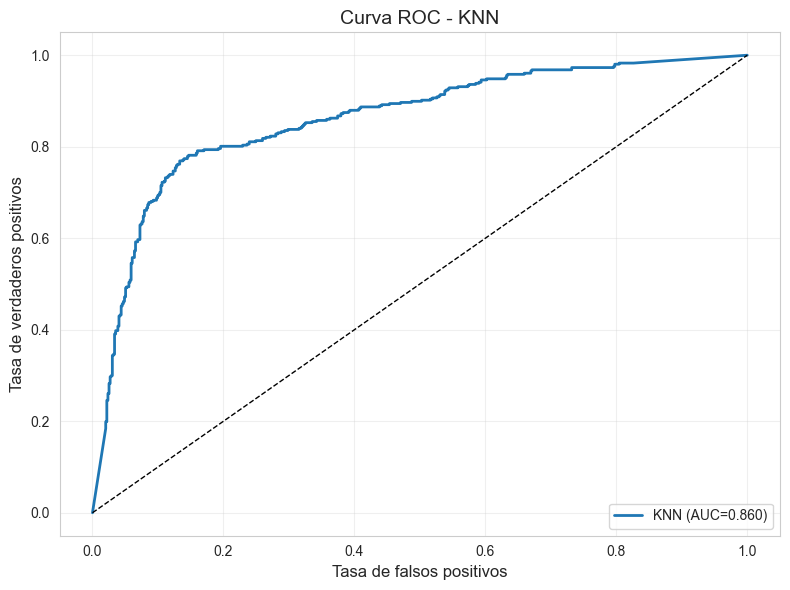

ROC guardada en: resultadosML\roc_KNN.png


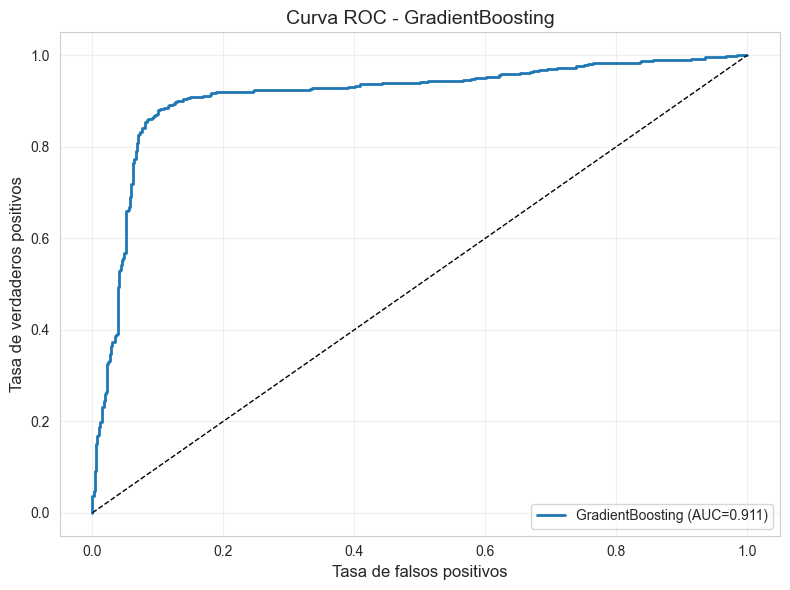

ROC guardada en: resultadosML\roc_GradientBoosting.png


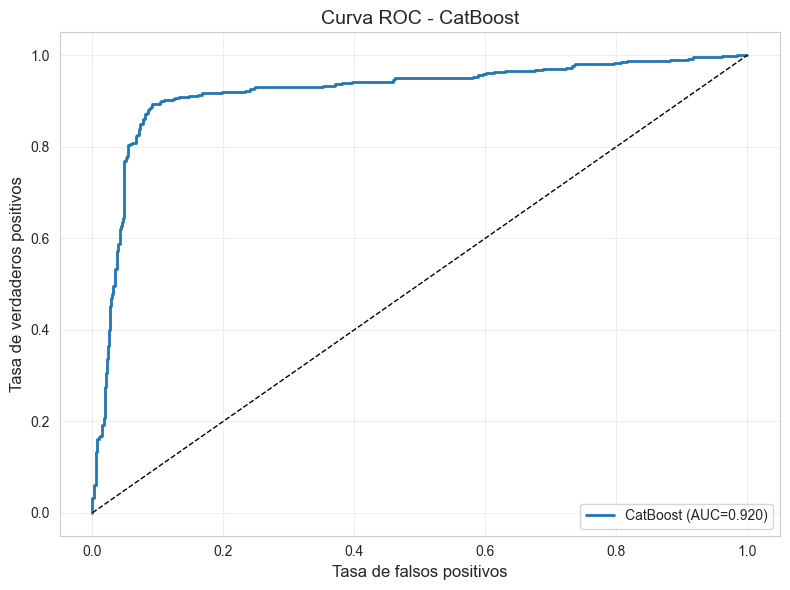

ROC guardada en: resultadosML\roc_CatBoost.png

Curvas ROC guardadas en la carpeta 'resultadosML/'


In [39]:
for name, model in best_models.items():
    plt.figure(figsize=(8, 6))

    try:
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    except:
        y_proba = model.decision_function(X_test_scaled)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

    plt.xlabel('Tasa de falsos positivos', fontsize=12)
    plt.ylabel('Tasa de verdaderos positivos', fontsize=12)
    plt.title(f'Curva ROC - {name}', fontsize=14)
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Guardar directamente en resultadosML
    file_path_roc = os.path.join(output_dir, f"roc_{name}.png")
    plt.savefig(file_path_roc, dpi=150)

    plt.show()
    plt.close()

    print(f"ROC guardada en: {file_path_roc}")

print("\nCurvas ROC guardadas en la carpeta 'resultadosML/'")

## Seleción del mejor modelo

In [40]:
results_df['Score'] = results_df['Recall'] + results_df['AUC']
best_model_name = results_df['Score'].idxmax()
best_model = best_models[best_model_name]
print(f"\nMejor modelo seleccionado: {best_model_name}")
print(f"Recall: {results_df.loc[best_model_name, 'Recall']:.4f}, AUC: {results_df.loc[best_model_name, 'AUC']:.4f}")


Mejor modelo seleccionado: LogisticRegression
Recall: 0.9042, AUC: 0.9217


### XAI con SHAP


Generando explicaciones SHAP para el mejor modelo...
Rango de shap_values: -3.328439377168893 3.2583343438299566
Media absoluta por característica (primeras 5): [0.01695641 0.14078272 0.13109415 0.12555097 0.16159916]


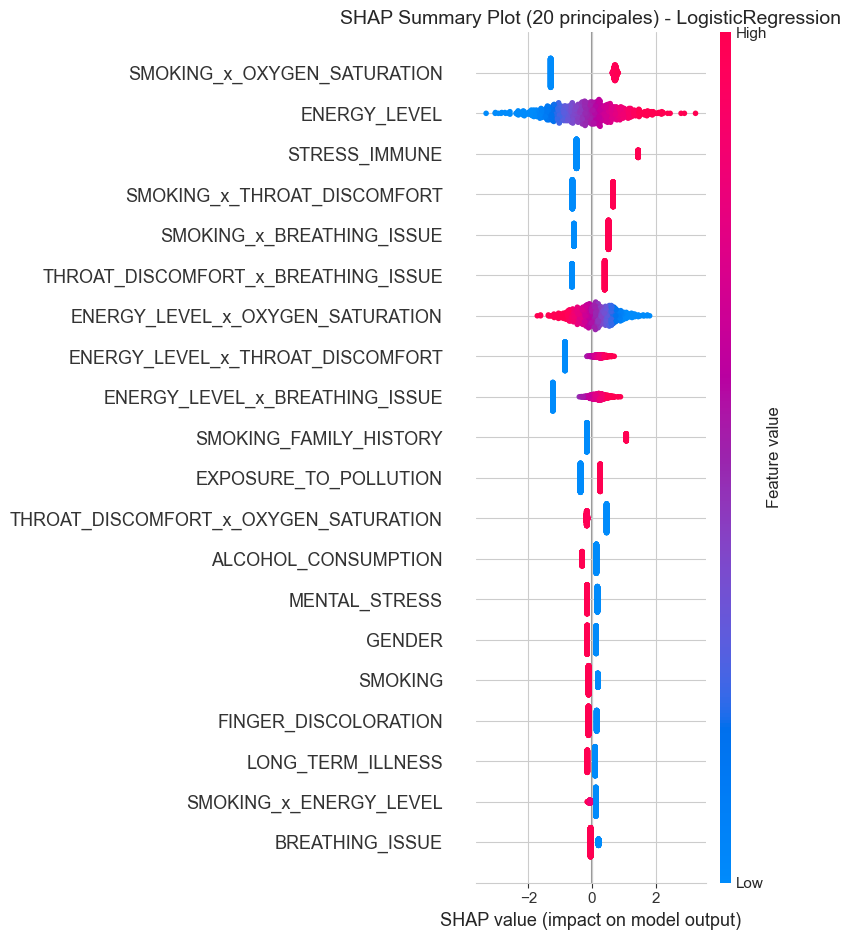

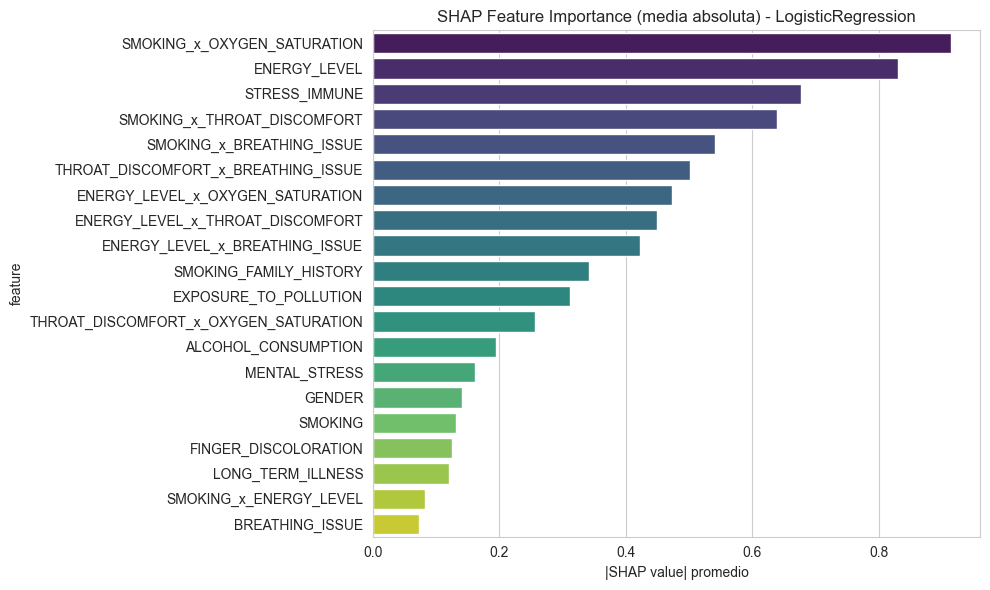

In [47]:
print("\nGenerando explicaciones SHAP para el mejor modelo...")
X_test_shap = X_test_scaled.copy()

# Selección de XAI según modelo
if best_model_name in ['RandomForest', 'XGBoost', 'GradientBoosting', 'CatBoost']:
  # Modelos básados en árboles: TreeExplainer
  explainer = shap.TreeExplainer(best_model)
  shap_values = explainer.shap_values(X_test_shap)
  if isinstance(shap_values, list):
    shap_values = shap_values[1]

else:
  # Modelos lineales: KernelExplainer, LogisticRegression
  background = shap.sample(X_train_resampled, 100) 
  explainer = shap.LinearExplainer(best_model, X_train_resampled)
  shap_values = explainer.shap_values(X_test_shap)
  if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Limitar a 20 características más importantes en valor absoluto medio
mean_abs_shap = np.abs(shap_values).mean(axis=0)
print("Rango de shap_values:", shap_values.min(), shap_values.max())
print("Media absoluta por característica (primeras 5):", mean_abs_shap[:5])
top_indices = np.argsort(mean_abs_shap)[-20:]  # índices de las 20 mayores
top_feature_names = X_test_shap.columns[top_indices]
shap_values_top = shap_values[:, top_indices]
X_test_top = X_test_shap.iloc[:, top_indices]

# Grafico de resumen
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_top, X_test_top, feature_names=top_feature_names, show=False)
plt.title(f'SHAP Summary Plot (20 principales) - {best_model_name}', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "shap_summary_top20.png"), bbox_inches='tight')
plt.show()

# Bar plot de importancia global
shap_importance = pd.DataFrame({
    'feature': X_test_shap.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=shap_importance, y='feature', x='mean_abs_shap', palette='viridis')
plt.title(f'SHAP Feature Importance (media absoluta) - {best_model_name}')
plt.xlabel('|SHAP value| promedio')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "shap_importance_bar.png"))
plt.show()

El análisis SHAP evidencia que las variables más influyentes en la predicción corresponden principalmente a interacciones entre factores clínicos y conductuales, destacando la combinación de tabaquismo y saturación de oxígeno. Asimismo, se observa que variables individuales presentan menor impacto en comparación con sus interacciones, lo cual sugiere que el modelo captura relaciones no lineales complejas entre los predictores.